# Exploratory data analysis (EDA)
_https://arxiv.org/html/2510.22916v1_

## First walk_throught

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')

### Check given data

In [2]:
# check file available
MAIN_DIR = Path("/kaggle/input/csiro-biomass/")
for el in MAIN_DIR.rglob("*"):
    if not el.suffix == ".jpg":
        print(el) 

/kaggle/input/csiro-biomass/sample_submission.csv
/kaggle/input/csiro-biomass/train.csv
/kaggle/input/csiro-biomass/test.csv
/kaggle/input/csiro-biomass/test
/kaggle/input/csiro-biomass/train


In [3]:
# Get data
trainset = pd.read_csv("/kaggle/input/csiro-biomass/train.csv")
testset = pd.read_csv("/kaggle/input/csiro-biomass/test.csv")
submission = pd.read_csv("/kaggle/input/csiro-biomass/sample_submission.csv")

In [4]:
trainset.head()

,sample_id,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,target_name,target
0,ID1011485656__Dry_Clover_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Clover_g,0.0000
1,ID1011485656__Dry_Dead_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Dead_g,31.9984
2,ID1011485656__Dry_Green_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Green_g,16.2751
3,ID1011485656__Dry_Total_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Total_g,48.2735
4,ID1011485656__GDM_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,GDM_g,16.2750


### Check missing values

In [5]:
trainset.isna().sum().sum() # 0

np.int64(0)

### Check tabular data

In [6]:
# Extract tabular data
date = trainset["Sampling_Date"]
state = trainset["State"]
species = trainset["Species"]
ndvi = trainset["Pre_GSHH_NDVI"]
av_height = trainset["Height_Ave_cm"]

In [7]:
# Analyse tabular data
date.dtype # Object
year = date.apply(lambda row: int(row.split("/")[0]))
month = date.apply(lambda row: int(row.split("/")[1]))
month.dtype # int64
month.nunique() # 10

state.dtype # Object
state.nunique() # 4 ['Tas', 'NSW', 'WA', 'Vic'] => one hot encoding
species.nunique() # 15 => one hot encoding 
ndvi.dtype # float64 (it seem between 0 & 1)
av_height.dtype; # float64 => To scale

### Check image sample & dimension

In [8]:
# Image sample
# from PIL import Image

# im = Image.open(MAIN_DIR / "train/ID1011485656.jpg")
# largeur, hauteur = im.size
# print("Largeur :", largeur)
# print("Hauteur :", hauteur)
# im

### Check target constraint & distribution

#### Target Constraint

In [9]:
trainset.target.max(), trainset.target.min()

(185.7, 0.0)

In [10]:
target = trainset.target.to_numpy().reshape((-1, 5))
target_df = pd.DataFrame(target, columns=["Dry_Clover_g", "Dry_Dead_g", "Dry_Green_g", "Dry_Total_g", "GDM_g"])

def get_each_target(target):
    """return: clover, dead, green, total, dmg"""
    return target[:, 0], target[:, 1], target[:, 2], target[:, 3], target[:, 4]

# take actual value
clover, dead, green, total, dmg = get_each_target(target)

In [11]:
# Math constaint
np.isclose(dmg, green + clover, rtol=1e-4).all(), np.isclose(total, green + clover + dead, rtol=1e-4).all()

(np.True_, np.False_)

In [12]:
mask = ~np.isclose(total, green + clover + dead, rtol=1e-4)
arg = np.argwhere(mask) # 1 element
total[arg], (green + clover + dead)[arg] # 10.19 vs 10.50

(array([[10.1912]]), array([[10.5]]))

#### Target distribution

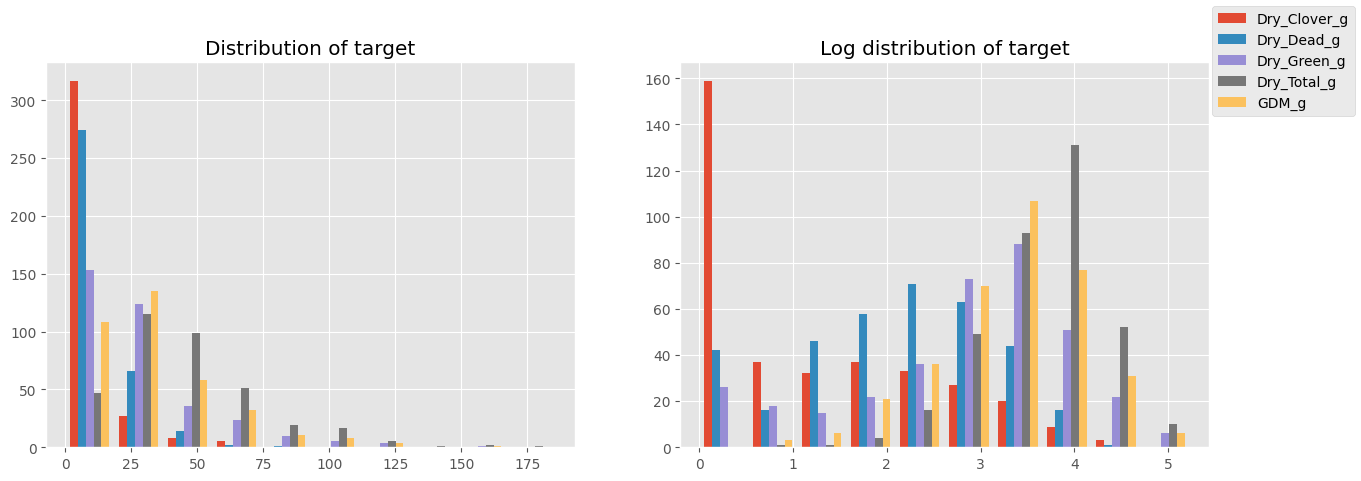

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# distribution of target:
ax1.hist(target)
ax1.set_title("Distribution of target")

# justify log transform
y_log = np.log1p(target)
ax2.hist(y_log, label=target_df.columns);
ax2.set_title("Log distribution of target")

fig.legend();

# Observation : right-skewed distributions ==> apply log to the target
# To stabilize variance and improve model evaluation robustness, 
# particularly for variables with high dynamic range or right-skewed distributions, 
# a log-stabilizing transformation is applied to all target variables before computing R2 values:

### Features Distribution: State, Species, average height, NDVI, Date

array([0.39, 0.21, 0.09, 0.31])

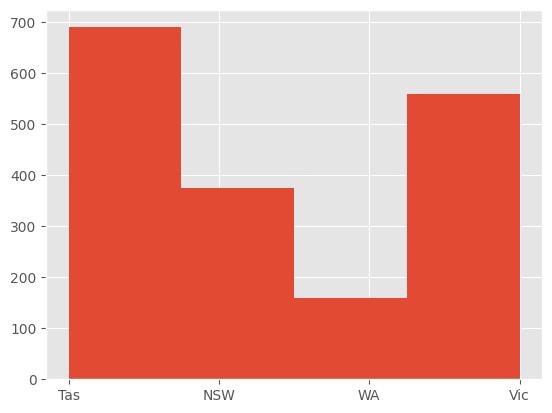

In [14]:
values, *_ = plt.hist(state, bins=state.nunique())
percent = values/values.sum()
np.round(percent,2)
# tas: 39% 
# nsw: 21%
# wa: 9%
# vic: 31%

array([0.27, 0.06, 0.01, 0.17, 0.12, 0.01, 0.11, 0.03, 0.02, 0.02, 0.03,
       0.08, 0.03, 0.02, 0.01])

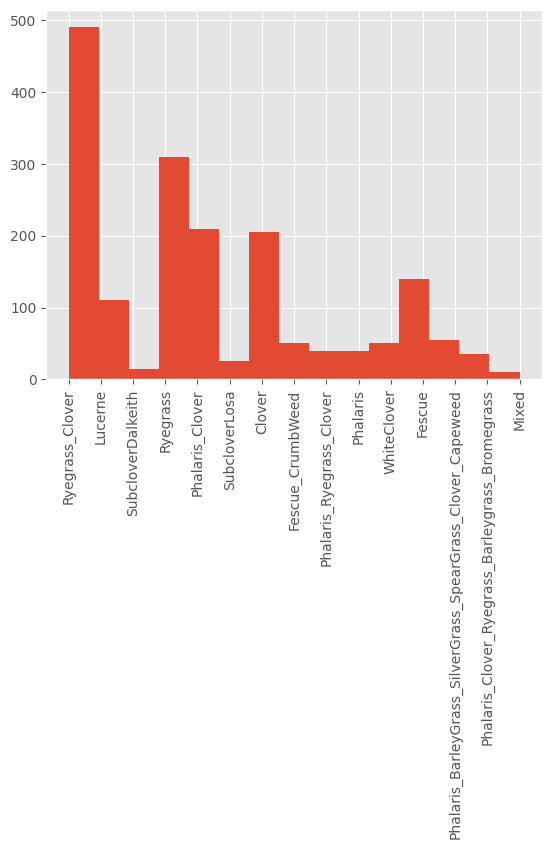

In [15]:
values, *_ = plt.hist(species, bins=species.nunique())
plt.xticks(rotation='vertical');

percent = values/values.sum()
np.round(percent,2) # Mainly "ryegrass_clover" at 27% then "Ryegrass" at 17% etc

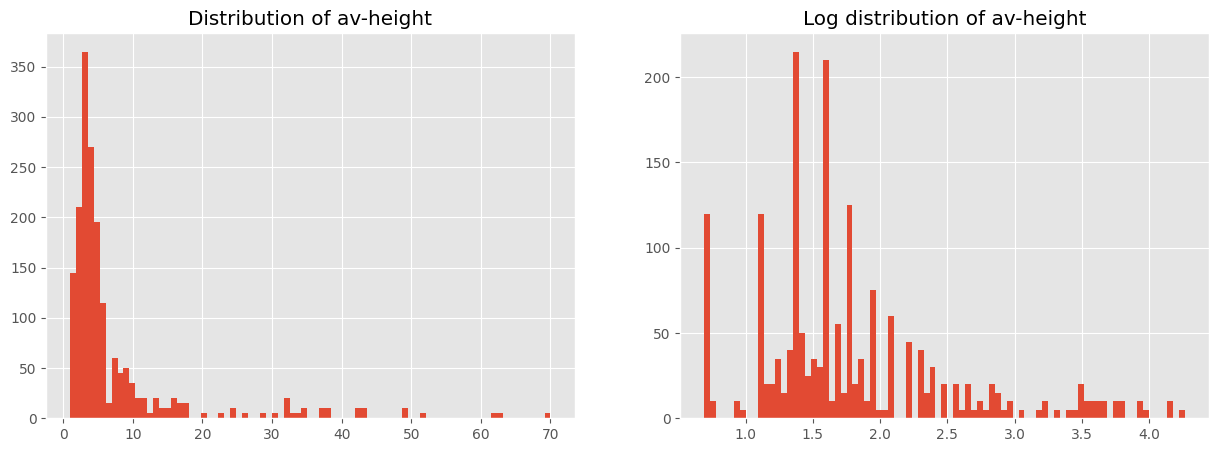

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# distribution of target:
ax1.hist(av_height, bins=av_height.nunique());
ax1.set_title("Distribution of av-height")

# justify log transform
av_height_log = np.log1p(av_height)
ax2.hist(av_height_log, bins=av_height.nunique())
ax2.set_title("Log distribution of av-height");

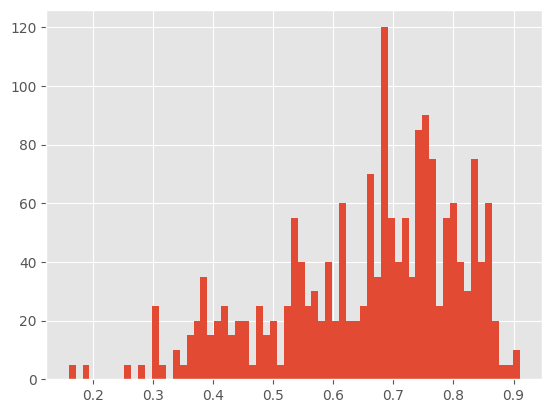

In [17]:
plt.hist(ndvi, bins=ndvi.nunique());

,sep,apr,may,jul,jun,jan,nov,feb,aug,oct
%,0.19,0.03,0.12,0.11,0.15,0.05,0.1,0.07,0.1,0.08


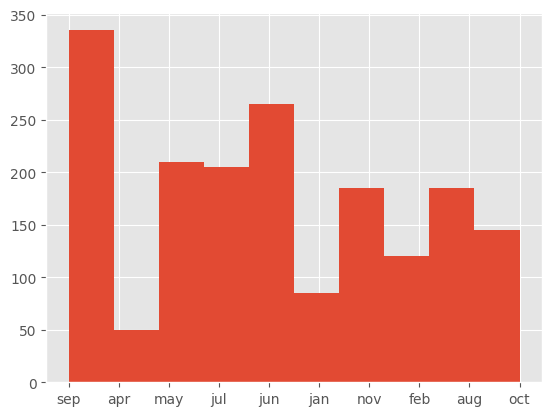

In [18]:
month_dic = {1:"jan", 2:"feb", 4:"apr", 5:"may", 6:"jun", 7:"jul", 8:"aug", 9:"sep", 10:"oct", 11:"nov"}
month_str = month.apply(lambda row: month_dic[row])
values, *_ = plt.hist(month_str, bins=month_str.nunique());
percent = values/values.sum()
pd.DataFrame({"%":np.round(percent,2)}, index=month_str.unique()).T

In [19]:
year.unique() # all date are within 2015

array([2015])

## Conclusion

- Dataset Structure: <br> Training set: 357 images with 5 target biomass components each (1,785 rows total)
<br>All images normalized to `2000 x 1000` pixels (70cm × 30cm quadrat, ~28.5 px/cm)
<br>Test set: ~800+ images (hidden during competition), only image paths available

- Available Features: <br>Training only: tabular data `[date, state, species, ndvi, Average height]`

- Train & Test: Images only

- Leverage Target Relationships -> *The targets have mathematical constraints*:

>`GDM_g = Dry_Green_g + Dry_Clover_g`
<br>
`Dry_Total_g = Dry_Green_g + Dry_Dead_g + Dry_Clover_g`
<br>
**considering: Predict 3 base components → derive the other 2**


### Suggested Approaches (Ideas Only)
Given the constraint that only images are available at test time, here are viable strategies:
1. Pure Vision Model (Baseline): <br>CNN/ViT trained directly on images → 5 regression outputs
Architectures: EfficientNet, ConvNeXt, Swin Transformer
Multi-task learning with shared backbone

2. Knowledge Distillation from Tabular Data: <br> *Since tabular features are strong predictors during training:* <br>Train a "teacher" model using image + tabular features
Distill knowledge to a "student" model that uses only images
The student learns to implicitly predict NDVI/height from visual cues

3. Auxiliary Task Learning: <br>Train CNN to predict NDVI and height as auxiliary outputs
These intermediate predictions inform the final biomass prediction
Forces the network to learn vegetation density/structure features



## Tabular model (training only): "Teacher" model
**(not available for final inference)**


In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn import __version__
__version__

'1.6.1'

In [21]:
target = trainset.target.to_numpy()
target = target.reshape((-1, 5)) 
target.shape, target[0:2]

((357, 5),
 array([[ 0.    , 31.9984, 16.2751, 48.2735, 16.275 ],
        [ 0.    ,  0.    ,  7.6   ,  7.6   ,  7.6   ]]))

In [22]:
def gen_tabular_features(initial_df):
    df = initial_df.drop(["target", "target_name", "sample_id", "image_path"], axis=1)
    df = df[0:-1:5].reset_index(drop=True)
    df.Height_Ave_cm = np.log1p(df.Height_Ave_cm)
    
    df.Sampling_Date = pd.to_datetime(df.Sampling_Date)
    df.rename(columns={"Sampling_Date":"Date", "Pre_GSHH_NDVI":"NDVI"}, inplace=True)
    return df

train_df = gen_tabular_features(trainset)
train_df.head()

,Date,State,Species,NDVI,Height_Ave_cm
0,2015-09-04,Tas,Ryegrass_Clover,0.62,1.734607
1,2015-04-01,NSW,Lucerne,0.55,2.833213
2,2015-09-01,WA,SubcloverDalkeith,0.38,0.693147
3,2015-05-18,Tas,Ryegrass,0.66,1.791759
4,2015-09-11,Tas,Ryegrass,0.54,1.504077


In [23]:
X_train, X_test, y_train, y_test = train_test_split(train_df, target, test_size=0.2, random_state=42)
y_train_log = np.log1p(y_train) # np.log1p(x) = log(1 + y)
y_test_log = np.log1p(y_test)

In [24]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

categorical_features = ["State", "Species"]
numerical_features = ["NDVI", "Height_Ave_cm"]

####################################
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",  
    sparse_output=False # False to get a dense array 
)

####################################
scaler = StandardScaler()

####################################
def cyclical_day_encoder(X):
    day = pd.to_datetime(X.iloc[:, 0]).dt.dayofyear
    sin = np.sin(2 * np.pi * day / 365)
    cos = np.cos(2 * np.pi * day / 365)
    return np.c_[sin, cos]

date_transformer = FunctionTransformer(
    cyclical_day_encoder,
    validate=False,
    feature_names_out=lambda self, input_features: [ 
        f"{input_features[0]}_sin",
        f"{input_features[0]}_cos",
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features),
        ("num", scaler, numerical_features),
        ("date", date_transformer, ["Date"]),
    ]
)

In [25]:
X_encoded = preprocessor.fit_transform(X_train)
X_encoded_df = pd.DataFrame(X_encoded, columns=preprocessor.get_feature_names_out())
X_encoded_df.head()

,cat__State_NSW,cat__State_Tas,cat__State_Vic,cat__State_WA,cat__Species_Clover,cat__Species_Fescue,cat__Species_Fescue_CrumbWeed,cat__Species_Lucerne,cat__Species_Mixed,cat__Species_Phalaris,...,cat__Species_Phalaris_Ryegrass_Clover,cat__Species_Ryegrass,cat__Species_Ryegrass_Clover,cat__Species_SubcloverDalkeith,cat__Species_SubcloverLosa,cat__Species_WhiteClover,num__NDVI,num__Height_Ave_cm,date__Date_sin,date__Date_cos
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.747845,0.215806,0.008607,-0.999963
1,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.432963,-1.502833,-0.111659,-0.993747
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.288642,-0.551919,0.008607,-0.999963
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-1.088968,-0.452704,-0.977848,0.209315
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.682245,-0.245793,-0.680773,-0.732494


In [26]:
model_tab = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        max_depth=5,
        min_samples_leaf=2,
        n_jobs=-1,
        )
    )
])

In [27]:
model_tab.fit(X_train, y_train_log)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['State', 'Species']),
                                                 ('num', StandardScaler(),
                                                  ['NDVI', 'Height_Ave_cm']),
                                                 ('date',
                                                  FunctionTransformer(feature_names_out=<function <lambda> at 0x7e09565b3380>,
                                                                      func=<function cyclical_day_encoder at 0x7e09565b2fc0>),
                                                  ['Date'])])),
                ('regressor',
                 RandomForestRegressor(max_depth=5, min_samples_leaf=2,
                                       n_estimators=300, n_jobs=-1,
                                       random_state=42))])

In [34]:
def diff_target_math_constraint(y_pred, return_mean=True):
    """return: dmg diff, total diff. Between 'calculated and predicted' values, round 4 digit"""
    clover, dead, green, total, dmg = get_each_target(y_pred)
    dmg_constraint = clover + green
    total_constraint = dmg_constraint + dead
    dmg_diff = np.abs((dmg_constraint - dmg).sum())
    total_diff = np.abs((total_constraint - total).sum())
    dmg_diff = dmg_diff/dmg.size if return_mean else dmg_diff
    total_diff = total_diff/total.size if return_mean else total_diff
    return np.round(dmg_diff, 4), np.round(total_diff, 4)

y_pred_log = model_tab.predict(X_test)
diff_target_math_constraint(np.expm1(y_pred_log)) # is the model learning the math constraint ? => want close to 0

(np.float64(2.909), np.float64(5.8064))

## CSIRO globally weighted coefficient of determination : $R^2_w$
Each row is weighted according to its target type using the following weights:
- Dry_Clover_g: 0.1
- Dry_Dead_g: 0.1
- Dry_Green_g: 0.1
- GDM_g: 0.2
- Dry_Total_g: 0.5

$$R^2_w = 1 - \frac{\sum_j w_j (y_j - \hat{y}_j)^2}{\sum_j w_j (y_j - \bar{y}_w)^2}$$
Where : $$\bar{y}_w = \frac{\sum_j w_j y_j}{\sum_j w_j}$$

- $y_j$: ground-truth value for data point 
- $\hat{y}_j$: model prediction for data point 
- :$w_j$ per-row weight based on target type
- $\bar{y}_w$: global weighted mean of all ground-truth values

In [29]:
def get_each_target(target):
    """return: clover, dead, green, total, dmg"""
    return target[:, 0], target[:, 1], target[:, 2], target[:, 3], target[:, 4]


def get_weights():
    """Each row is weighted accordily"""
    return {"clover":0.1, "dead":0.1, "green":0.1,"total":0.5, "dmg":0.2}

def Yw(y_true):
    """global weighted mean of all ground-truth values"""
    each_target_size = y_true.shape[0] # output for each prediction
    weights = get_weights()
    N = sum(w*targ for w, targ in zip(weights.values(), get_each_target(y_true)))
    D = sum(weights.values()) * each_target_size
    return (N/D).sum()

def SSres(y_true, y_pred):
    """Measures the total error of the model’s predictions"""
    weights = get_weights()
    SS = sum(w*np.square(targ_true - targ_pred) 
             for w, targ_true, targ_pred 
             in zip(weights.values(), get_each_target(y_true), get_each_target(y_pred))
            )
    return SS.sum()

def SStot(y_true):
    """Measures the total weighted variance in the data"""
    y_w = Yw(y_true)
    weights = get_weights()
    SS = sum(w*np.square(targ_true - y_w) 
             for w, targ_true 
             in zip(weights.values(), get_each_target(y_true))
            )
    return SS.sum()

def r2_csiro(y_true, y_pred):
    """Globally weighted coefficient of determination"""
    SS_res = SSres(y_true, y_pred)
    SS_tot = SStot(y_true)
    return 1 - SS_res / SS_tot
 

In [30]:
y_pred_log = model_tab.predict(X_test)

r2_test = r2_csiro(y_test_log, y_pred_log)
r2_train = r2_csiro(y_train_log, model_tab.predict(X_train))

print(f"Test Score: {r2_test:.3f}")
print(f"\nOverfitting ?\nTrain score:, {r2_train:.3f}")  # gap between train & test 

Test Score: 0.814

Overfitting ?
Train score:, 0.881


### Features importances

In [31]:
import pandas as pd
import numpy as np

rf = model_tab.named_steps["regressor"] # RandomForestRegressor
feature_names = model_tab.named_steps["preprocessing"].get_feature_names_out()
importances = rf.feature_importances_
feat_imp = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False)

def aggregate_features_importance_df(features_importance):
    features_importance["group"] = features_importance["feature"].str.replace(r"^cat__|^num__", "", regex=True)
    features_importance["group"] = features_importance["group"].str.split("_").str[0]
    
    grouped_imp = (
        features_importance
        .groupby("group", as_index=False)["importance"]
        .sum()
        .sort_values("importance", ascending=False)
    )
    return grouped_imp

aggregate_features_importance_df(feat_imp)

,group,importance
0,Height,0.390927
3,State,0.185625
2,Species,0.151683
4,date,0.137235
1,NDVI,0.134530


In [32]:
from sklearn.inspection import permutation_importance

X_enc = model_tab.named_steps["preprocessing"].transform(X_train)

r = permutation_importance(
    model_tab.named_steps["regressor"],
    X_enc,
    y_train_log,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_imp = pd.DataFrame({
    "feature": model_tab.named_steps["preprocessing"].get_feature_names_out(),
    "importance": r.importances_mean
}).sort_values("importance", ascending=False)

In [33]:
agg_feat_importance = aggregate_features_importance_df(perm_imp)
agg_feat_importance

,group,importance
0,Height,0.617985
1,NDVI,0.200571
3,State,0.164115
4,date,0.129954
2,Species,0.123431


# CNN Model

In [50]:
import torch
from torch.utils.data import Dataset
from PIL import Image
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device, torch.__version__

(device(type='cuda'), '2.8.0+cu126')

## DataSet

In [51]:
class ImageTabularRegressionDataset(Dataset):
    def __init__(self, image_df, X_tab, targets, transform=None):
        self.image_df = image_df.reset_index(drop=True)
        self.X_tab = torch.tensor(X_tab, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)
        self.transform = transform

    def __len__(self):
        return len(self.image_df)

    def __getitem__(self, idx):
        # image
        img_path = self.image_df.loc[idx, "image_path"]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        # tabulaire
        tab = self.X_tab[idx]

        # target
        target = self.targets[idx]

        return image, tab, target
 

In [52]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], # Ce sont les statistiques (moyenne / écart-type) calculées sur ImageNet, 
        std=[0.229, 0.224, 0.225], # le dataset sur lequel EfficientNet a été pré-entraîné.
    )
])

val_transform = transforms.Compose([
      transforms.Resize((224, 224)),
      transforms.ToTensor(),
      transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
  ])

In [53]:
X = gen_tabular_features(trainset)
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)
X_train.head(2)

,Date,State,Species,NDVI,Height_Ave_cm
282,2015-07-01,Vic,Phalaris_Clover,0.77,1.945910
333,2015-07-08,WA,Clover,0.59,0.693147


In [54]:
def gen_data_for_DL(initial_df):
    
    tab_df = gen_tabular_features(initial_df)
    
    image_df = initial_df[["image_path"]].loc[0::5].reset_index(drop=True)
    image_df = image_df.apply(lambda row: (MAIN_DIR / row))

    targets = initial_df.target.to_numpy()
    targets = targets.reshape((-1, 5)) 
    targets = np.log1p(targets)
    
    image_train, image_test, tab_train, tab_test, y_train, y_test = train_test_split(image_df, 
                                                                                     tab_df, 
                                                                                     targets, 
                                                                                     test_size=0.2, 
                                                                                     random_state=42)
    
    scaler = StandardScaler()
    encoder_species = LabelEncoder()
    encoder_state = LabelEncoder()
    tab_train_processes = scaler.fit_transform(tab_train[["NDVI", "Height_Ave_cm"]])
    tab_train_processes = pd.DataFrame(tab_train_processes, columns=scaler.get_feature_names_out())
    tab_train_processes["Species"] = encoder_species.fit_transform(tab_train["Species"])
    tab_train_processes["State"] = encoder_state.fit_transform(tab_train["State"])

    tab_test_precesses = scaler.transform(tab_test[["NDVI", "Height_Ave_cm"]])
    tab_test_processes = pd.DataFrame(tab_test_precesses, columns=scaler.get_feature_names_out())
    tab_test_processes["Species"] = encoder_species.transform(tab_test["Species"])
    tab_test_processes["State"] = encoder_state.transform(tab_test["State"])

    images = (image_train, image_test)
    tab_processes = (tab_train_processes, tab_test_processes)
    targets = (y_train, y_test)
    
    return images, tab_processes, targets, [scaler, encoder_species, encoder_state]

images, tab_processes, targets, preprocessing = gen_data_for_DL(trainset)
(image_train, image_test), (tab_train, tab_test), (y_train, y_test) = images, tab_processes, targets


In [55]:
display(tab_train.head(3)), display(image_train.head(2));

,NDVI,Height_Ave_cm,Species,State
0,0.747845,0.215806,7,2
1,-0.432963,-1.502833,0,3
2,0.288642,-0.551919,7,2


,image_path
282,/kaggle/input/csiro-biomass/train/ID629980789.jpg
333,/kaggle/input/csiro-biomass/train/ID866684633.jpg


In [56]:
from torch.utils.data import DataLoader

def get_dataloader(image, tabular, y_label, training=True, transform=None):
    if isinstance(tabular, pd.DataFrame):
        tabular = tabular.to_numpy()
    dataset = ImageTabularRegressionDataset(
        image,
        tabular,
        y_label,
        transform=transform
    )
    
    loader = DataLoader(
        dataset=dataset,
        batch_size=32,
        shuffle=training,
        num_workers=4,
        pin_memory=True
    )
    return loader

train_loader = get_dataloader(image_train, tab_train, y_train, transform=train_transform)
test_loader = get_dataloader(image_test, tab_test, y_test, training=False, transform=val_transform)

## Modeling

In [138]:
import torch
import torch.nn as nn
import timm

class MultiTaskBiomassModel(nn.Module):
    def __init__(self, num_species=15, num_state=4):
        super().__init__()
        
        # Shared backbone
        self.backbone = timm.create_model('efficientnet_b0', pretrained=True, num_classes=0)
        feature_dim = self.backbone.num_features  # 1280 for efficientnet_b0
        self.dropout = nn.Dropout(0.3)
        
        # Auxiliary heads (predict privileged features)
        self.height_head = nn.Linear(feature_dim, 1)      # Regression
        self.ndvi_head = nn.Linear(feature_dim, 1)        # Regression
        self.species_head = nn.Linear(feature_dim, num_species) # Classification. No softmax, include in CrossEntropyLoss
        self.state_head = nn.Linear(feature_dim, num_state) # Calssification
        
        # Main task head (predict biomass)
        self.biomass_head = nn.Sequential(
            nn.Linear(feature_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 5)  # 5 biomass targets
        )
    
    def forward(self, x):
        x = self.backbone(x)
        features = self.dropout(x)
        
        return {
            'biomass': self.biomass_head(features),
            'height': self.height_head(features),
            'ndvi': self.ndvi_head(features),
            'species': self.species_head(features),
            'state': self.state_head(features)
        }


class WeightedMSELoss(nn.Module):
    def __init__(self):
        super().__init__()
        # Ordre colonnes : clover, dead, green, total, gdm
        self.weights = torch.tensor([0.1, 0.1, 0.1, 0.5, 0.2])
    
    def forward(self, pred, target):
        w = self.weights.to(pred.device)
        sq_err = (pred - target) ** 2
        return (sq_err * w).mean()


class MultiTaskLoss(nn.Module):
    def __init__(self, aux_weight=0.3):
        super().__init__()
        self.aux_weight = aux_weight
        self.wmse = WeightedMSELoss()
        self.mse = nn.MSELoss()
        self.ce = nn.CrossEntropyLoss()

    def _get_tabular_target(self, tab, name):
        if name == "ndvi":
            return tab[:, 0].reshape((-1, 1))
        elif name == "height":
            return tab[:, 1].reshape((-1, 1))
        elif name == "species":
            return tab[:, 2].long()
        elif name == "state":
            return tab[:, 3].long()
        else:
            raise ValueError(f"Unknown tabular target: {name}")
    
    def forward(self, predictions, tab, targets):
        # Main loss (biomass) - most important
        loss_biomass = self.wmse(predictions['biomass'], targets)
        
        # Auxiliary losses (privileged features)
        loss_height = self.mse(predictions['height'], self._get_tabular_target(tab, "height"))
        loss_ndvi = self.mse(predictions['ndvi'], self._get_tabular_target(tab, "ndvi"))
        loss_species = self.ce(predictions['species'], self._get_tabular_target(tab, "species"))
        loss_state = self.ce(predictions['state'], self._get_tabular_target(tab, "state"))
        
        # Combine
        aux_loss = loss_height + loss_ndvi + loss_species + loss_state
        total_loss = loss_biomass + self.aux_weight * aux_loss

        return total_loss, {
            'biomass': loss_biomass.item(),
            'height': loss_height.item(),
            'ndvi': loss_ndvi.item(),
            'species': loss_species.item(),
            'state': loss_state.item()
        }



In [139]:
from time import perf_counter
from tqdm.auto import tqdm

def train_one_epoch(model, train_loader, optimizer, criterion, device):
    model.train()
    running_losses = {"loss": 0}

    for images, tab, targets in train_loader:
        images = images.to(device)
        targets = targets.to(device)
        tab = tab.to(device)

        optimizer.zero_grad()
        pred = model(images)
        if isinstance(criterion, MultiTaskLoss):
            loss, info = criterion(pred, tab, targets)
            for name, l in info.items():
                running_losses[name] = running_losses.get(name, 0) + l        
        else :
            loss = criterion(pred["biomass"], targets)

        running_losses["loss"] += loss.item()
        loss.backward()
        optimizer.step()
        

    return running_losses

eval_criterion = WeightedMSELoss()
def evaluate(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0
    with torch.inference_mode():
        y_true = torch.Tensor().to(device)
        predictions = torch.Tensor().to(device)
        for im, _, label in test_loader:
            im = im.to(device)
            label = label.to(device)
            pred = model(im)
            loss = criterion(pred["biomass"], label)
            running_loss += loss.item()

            y_true = torch.cat((y_true, label), axis=0)
            predictions = torch.cat((predictions, pred["biomass"]), axis=0)

    r2_score = r2_csiro(y_true=y_true.cpu(), y_pred=predictions.cpu())
    return running_loss, r2_score

In [140]:
def train(model, train_loader, optimizer, criterion, 
          epochs=10, test_loader=None, eval_criterion=None, 
          patience=5, save_path="best_model.pt"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    training_losses = []
    aux_losses = []
    eval_losses = []
    r2_scores = []
    best_r2 = -float("inf")
    patience_counter = 0
    best_state_dict = model.state_dict()
    for epoch in tqdm(range(epochs)):
        losses = train_one_epoch(model, train_loader, optimizer, criterion, device)
        training_losses.append(losses)
        print(f"Epoch {epoch}:")
        for name, loss in losses.items():
            print(f"\tTraining: {name}={loss/len(train_loader):.4f}")

        if test_loader:
            eval_loss, r2 = evaluate(model, test_loader, eval_criterion, device) 
            eval_losses.append(eval_loss)
            r2_scores.append(r2)
            print(f"\tEval: loss={eval_loss/len(test_loader):.4f} r2_score: {r2}")

            # --- Save best; EarlyStopping ---
            if patience is None:
                continue
            if r2 > best_r2:
                best_r2 = r2
                best_state_dict = model.state_dict()
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"\nEarly stopping at epoch {epoch} (patience={patience})")
                    break
                    
    model.load_state_dict(best_state_dict)
    torch.save(best_state_dict, save_path)
    print(f"  → best model saved (r2={best_r2:.4f})")
    
    if test_loader:
        return pd.DataFrame(training_losses), np.array(eval_losses), np.array(r2_scores)
    return pd.DataFrame(training_losses)

In [141]:
%%time
epochs = 25
model = MultiTaskBiomassModel(num_species=preprocessing[1].classes_.size,
                             num_state=preprocessing[2].classes_.size)
training_criterion = MultiTaskLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
out = train(model, train_loader, optimizer, training_criterion, epochs, test_loader, eval_criterion)  

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch 0:
	Training: loss=3.7587
	Training: biomass=1.9727
	Training: height=0.9337
	Training: ndvi=0.9335
	Training: species=2.7324
	Training: state=1.3539
	Eval: loss=1.9349 r2_score: -6.677369117736816


/tmp/ipykernel_55/3234444202.py:21: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  SS = sum(w*np.square(targ_true - targ_pred)
/tmp/ipykernel_55/3234444202.py:31: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  SS = sum(w*np.square(targ_true - y_w)


Epoch 1:
	Training: loss=2.9683
	Training: biomass=1.4368
	Training: height=0.6930
	Training: ndvi=0.6158
	Training: species=2.5398
	Training: state=1.2565
	Eval: loss=1.3643 r2_score: -4.371551036834717
Epoch 2:
	Training: loss=2.2674
	Training: biomass=0.9401
	Training: height=0.4870
	Training: ndvi=0.4325
	Training: species=2.3380
	Training: state=1.1668
	Eval: loss=0.7271 r2_score: -1.9423818588256836
Epoch 3:
	Training: loss=1.7568
	Training: biomass=0.5719
	Training: height=0.3700
	Training: ndvi=0.3253
	Training: species=2.1773
	Training: state=1.0771
	Eval: loss=0.4440 r2_score: -0.8190641403198242
Epoch 4:
	Training: loss=1.4065
	Training: biomass=0.3413
	Training: height=0.2917
	Training: ndvi=0.2377
	Training: species=2.0080
	Training: state=1.0135
	Eval: loss=0.3631 r2_score: -0.40723109245300293
Epoch 5:
	Training: loss=1.1760
	Training: biomass=0.2127
	Training: height=0.2291
	Training: ndvi=0.2087
	Training: species=1.8456
	Training: state=0.9276
	Eval: loss=0.2998 r2_sc

In [142]:
_, r2_test = evaluate(model, test_loader, eval_criterion, device)
_, r2_train = evaluate(model, train_loader, eval_criterion, device)
print(f"Test Score: {r2_test:.3f}")
print(f"\nOverfitting ?\nTrain score:, {r2_train:.3f}")

/tmp/ipykernel_55/3234444202.py:21: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  SS = sum(w*np.square(targ_true - targ_pred)
/tmp/ipykernel_55/3234444202.py:31: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  SS = sum(w*np.square(targ_true - y_w)


Test Score: 0.587

Overfitting ?
Train score:, 0.871


<Axes: >

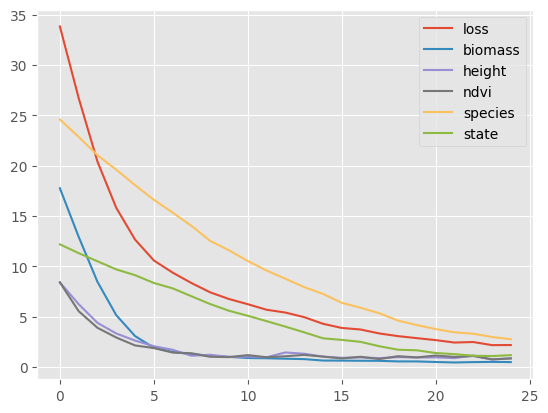

In [143]:
training_losses, eval_losses, r2_scores = out
training_losses.plot()

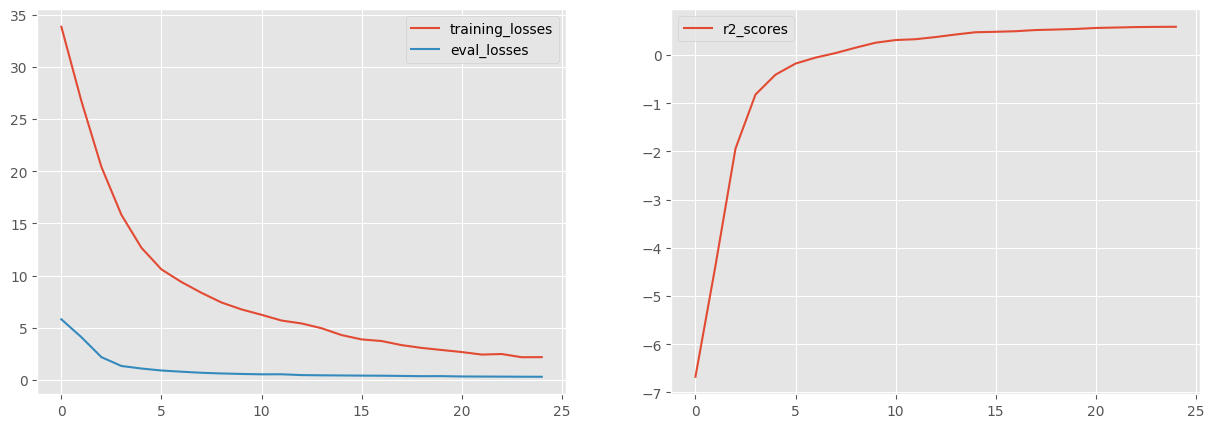

In [144]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.plot(training_losses["loss"], label="training_losses")
ax1.plot(eval_losses, label="eval_losses")
ax1.legend()

ax2.plot(r2_scores, label="r2_scores")
ax2.legend();

In [145]:
%%time
weighted_training_criterion = WeightedMSELoss() # use for comparaison
model2 = MultiTaskBiomassModel(num_species=preprocessing[1].classes_.size,
                             num_state=preprocessing[2].classes_.size)
optimizer2 = torch.optim.AdamW(model2.parameters(), lr=1e-4, weight_decay=1e-4)

out2 = train(model2, train_loader, optimizer2, weighted_training_criterion, epochs, test_loader, eval_criterion) #regular  

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch 0:
	Training: loss=1.8970
	Eval: loss=1.8556 r2_score: -6.4023613929748535


/tmp/ipykernel_55/3234444202.py:21: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  SS = sum(w*np.square(targ_true - targ_pred)
/tmp/ipykernel_55/3234444202.py:31: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  SS = sum(w*np.square(targ_true - y_w)


Epoch 1:
	Training: loss=1.3606
	Eval: loss=1.1874 r2_score: -3.703601360321045
Epoch 2:
	Training: loss=0.8649
	Eval: loss=0.6066 r2_score: -1.291738748550415
Epoch 3:
	Training: loss=0.4877
	Eval: loss=0.5257 r2_score: -0.9303526878356934
Epoch 4:
	Training: loss=0.2912
	Eval: loss=0.3177 r2_score: -0.2185901403427124
Epoch 5:
	Training: loss=0.1886
	Eval: loss=0.1852 r2_score: 0.2592071294784546
Epoch 6:
	Training: loss=0.1291
	Eval: loss=0.1503 r2_score: 0.38511401414871216
Epoch 7:
	Training: loss=0.1027
	Eval: loss=0.1334 r2_score: 0.4497787356376648
Epoch 8:
	Training: loss=0.0910
	Eval: loss=0.1322 r2_score: 0.4559747576713562
Epoch 9:
	Training: loss=0.0824
	Eval: loss=0.1305 r2_score: 0.4600270390510559
Epoch 10:
	Training: loss=0.0784
	Eval: loss=0.1182 r2_score: 0.5096970796585083
Epoch 11:
	Training: loss=0.0752
	Eval: loss=0.1212 r2_score: 0.4986327886581421
Epoch 12:
	Training: loss=0.0730
	Eval: loss=0.1145 r2_score: 0.5285013914108276
Epoch 13:
	Training: loss=0.0682
	

In [146]:
_, r2_test2 = evaluate(model2, test_loader, eval_criterion, device)
_, r2_train2 = evaluate(model2, train_loader, eval_criterion, device)
print(f"Test Score: {r2_test2:.3f}")
print(f"\nOverfitting ?\nTrain score:, {r2_train2:.3f}")

/tmp/ipykernel_55/3234444202.py:21: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  SS = sum(w*np.square(targ_true - targ_pred)
/tmp/ipykernel_55/3234444202.py:31: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  SS = sum(w*np.square(targ_true - y_w)


Test Score: 0.611

Overfitting ?
Train score:, 0.872


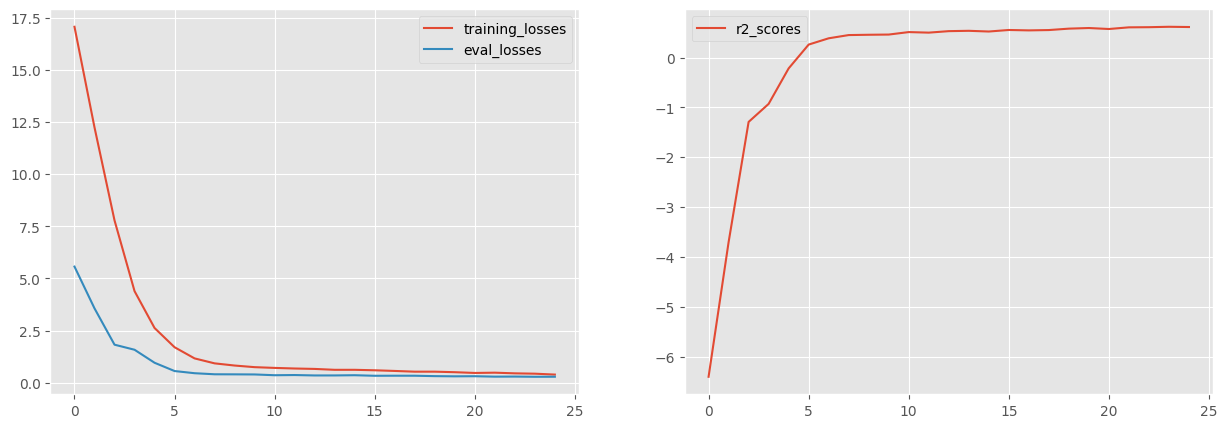

In [147]:
training_losses2, eval_losses2, r2_scores2 = out2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.plot(training_losses2["loss"], label="training_losses")
ax1.plot(eval_losses2, label="eval_losses")
ax1.legend()

ax2.plot(r2_scores2, label="r2_scores")
ax2.legend();

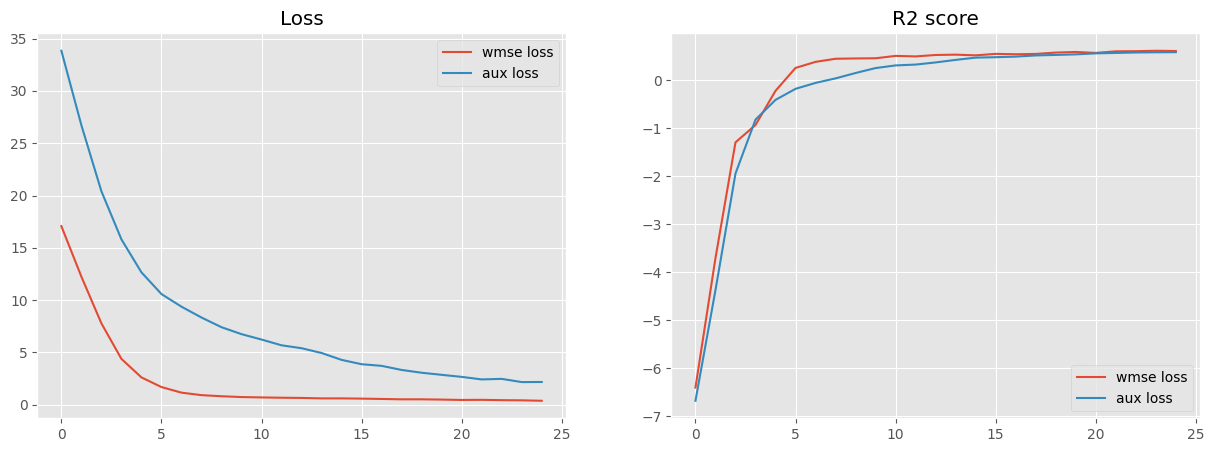

In [148]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.set_title("Loss")
ax1.plot(training_losses2["loss"], label="wmse loss")
ax1.plot(training_losses["loss"], label="aux loss")
ax1.legend()

ax2.set_title("R2 score")
ax2.plot(r2_scores2, label="wmse loss")
ax2.plot(r2_scores, label="aux loss")
ax2.legend();

# Submission

In [149]:
def get_submission_df(testset):
    sub_image_df = testset[["image_path"]].loc[::5]
    sub_image_df = sub_image_df.apply(lambda row: (MAIN_DIR / row))
    return sub_image_df
sub_image_df = get_submission_df(testset)
sub_image_df # 1 element

,image_path
0,/kaggle/input/csiro-biomass/test/ID1001187975.jpg


In [150]:
class SubmissionDataset(Dataset):
    def __init__(self, image_df, transform=None):
        self.image_df = image_df
        self.transform = transform

    def __len__(self):
        return len(self.image_df)

    def __getitem__(self, idx):
        img_path = self.image_df.loc[idx, "image_path"]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image

def get_submission_dataloader(testset):
    sub_image_df = get_submission_df(testset)
    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])
        ])
    
    sub_dataset = SubmissionDataset(sub_image_df, val_transform)
    
    return DataLoader(
        dataset=sub_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

In [151]:
def inference(model, testset, device=None):
    dataloader = get_submission_dataloader(testset)
    device = device if device else torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    with torch.inference_mode():
        preds = []
        for im in dataloader:
            im = im.to(device)
            pred = model(im)
            preds.append(pred["biomass"])
    return preds

In [152]:
log_preds = inference(model, testset)[0].cpu()

In [153]:
preds = np.expm1(log_preds)

/tmp/ipykernel_55/2415653074.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  preds = np.expm1(log_preds)


In [154]:
submission["target"] = preds[0] # only one prediction
submission

,sample_id,target
0,ID1001187975__Dry_Clover_g,0.544917
1,ID1001187975__Dry_Dead_g,26.517448
2,ID1001187975__Dry_Green_g,24.256536
3,ID1001187975__Dry_Total_g,57.220783
4,ID1001187975__GDM_g,24.249046


In [155]:
submission.to_csv("submission.csv", index=False)

In [156]:
diff_target_math_constraint(np.expand_dims(submission.target.to_numpy(), axis=0))

(np.float32(0.5524), np.float32(5.9019))